<a href="https://colab.research.google.com/github/vinkoff/Learner/blob/master/Apps_GENAI_MOD3_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hands on lab for GANS and VAES Coimpare Packet_size disstribution against the original with VAE and GAN

In [ ]:
#To print plot without Gradio
!pip install sdv pandas matplotlib seaborn
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import files
import io

# Import real synthetic data generators from SDV
from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer, CTGANSynthesizer
from scipy.stats import wasserstein_distance

# --- CORE SDV SYNTHETIC GENERATION LOGIC ---
def run_sdv_engine(epochs_input):
    # 1. Load data & trim down to core features to keep training lightning-fast on CPU
    df_full = pd.read_csv("cybersecurity_intrusion_data 2.csv")
    features = ['network_packet_size', 'session_duration']
    #features = ['login_attempts', 'session_duration']
    df_train = df_full[features].dropna().reset_index(drop=True)

    # 2. Let SDV auto-detect the schema metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(data=df_train)

    # 3. Instantiate and fit the real TVAE model
    vae_model = TVAESynthesizer(metadata, enforce_rounding=True, epochs=int(epochs_input))
    vae_model.fit(df_train)
    vae_synthetic = vae_model.sample(num_rows=len(df_train))

    # 4. Instantiate and fit the real CTGAN model
    gan_model = CTGANSynthesizer(metadata, enforce_rounding=True, epochs=int(epochs_input), verbose=False)
    gan_model.fit(df_train)
    gan_synthetic = gan_model.sample(num_rows=len(df_train))

    # 5. Extract target arrays for evaluation
    orig_vals = df_train['network_packet_size'].values
    vae_vals = vae_synthetic['network_packet_size'].values
    gan_vals = gan_synthetic['network_packet_size'].values

    #orig_vals = df_train['login_attempts'].values
    #vae_vals = vae_synthetic['login_attempts'].values
    #gan_vals = gan_synthetic['login_attempts'].values


    # 6. Calculate statistical metrics
    wd_vae = wasserstein_distance(orig_vals, vae_vals)
    wd_gan = wasserstein_distance(orig_vals, gan_vals)

    # 7. Generate Comparison Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.kdeplot(orig_vals, label="Original Data", color="black", linestyle="--", ax=ax)
    sns.kdeplot(vae_vals, label=f"SDV TVAE (WD: {wd_vae:.2f})", color="royalblue", ax=ax)
    sns.kdeplot(gan_vals, label=f"SDV CTGAN (WD: {wd_gan:.2f})", color="crimson", ax=ax)
    ax.set_title("Network Packet Size Distribution Analysis")
    ax.set_xlabel("Packet Size (Bytes)")

    #ax.set_title("login attempts Distribution Analysis")
    #ax.set_xlabel("login attempts (Bytes)")
    ax.legend()
    plt.tight_layout()

    plot_output_path = "sdv_distribution_chart.png"
    #plot_output_path = "login_attempts.png"
    plt.savefig(plot_output_path)
    plt.show()
    plt.close()

    metrics_summary = (
        f"📋 SDV ENGINE REVENUE SCOREBOARD:\n"
        f"• Samples Generated: {len(df_train)} rows\n"
        f"• VAE Wasserstein Distance: {wd_vae:.4f}\n"
        f"• GAN Wasserstein Distance: {wd_gan:.4f}\n\n"
        f"Notice how modifying the epoch slider changes model distribution quality."
    )
    return plot_output_path, metrics_summary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.5/204.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


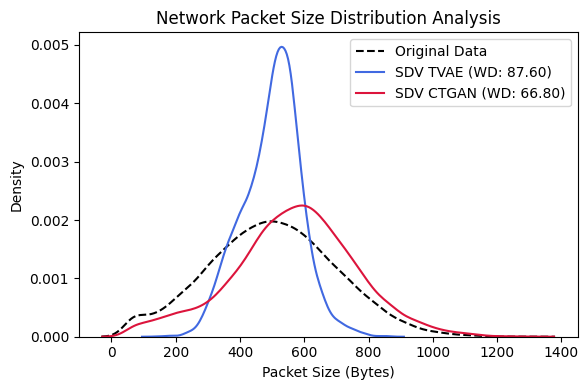

📋 SDV ENGINE REVENUE SCOREBOARD:
• Samples Generated: 9537 rows
• VAE Wasserstein Distance: 87.6017
• GAN Wasserstein Distance: 66.7969

Notice how modifying the epoch slider changes model distribution quality.


In [ ]:
#Call the function to plot
# Run the function manually to see the plot and print the text summary
img_path, text_summary = run_sdv_engine(epochs_input=10)

print(text_summary)

GANS and VAES to reconstruct images and compare to the original. Compute MSE to evaluate the image

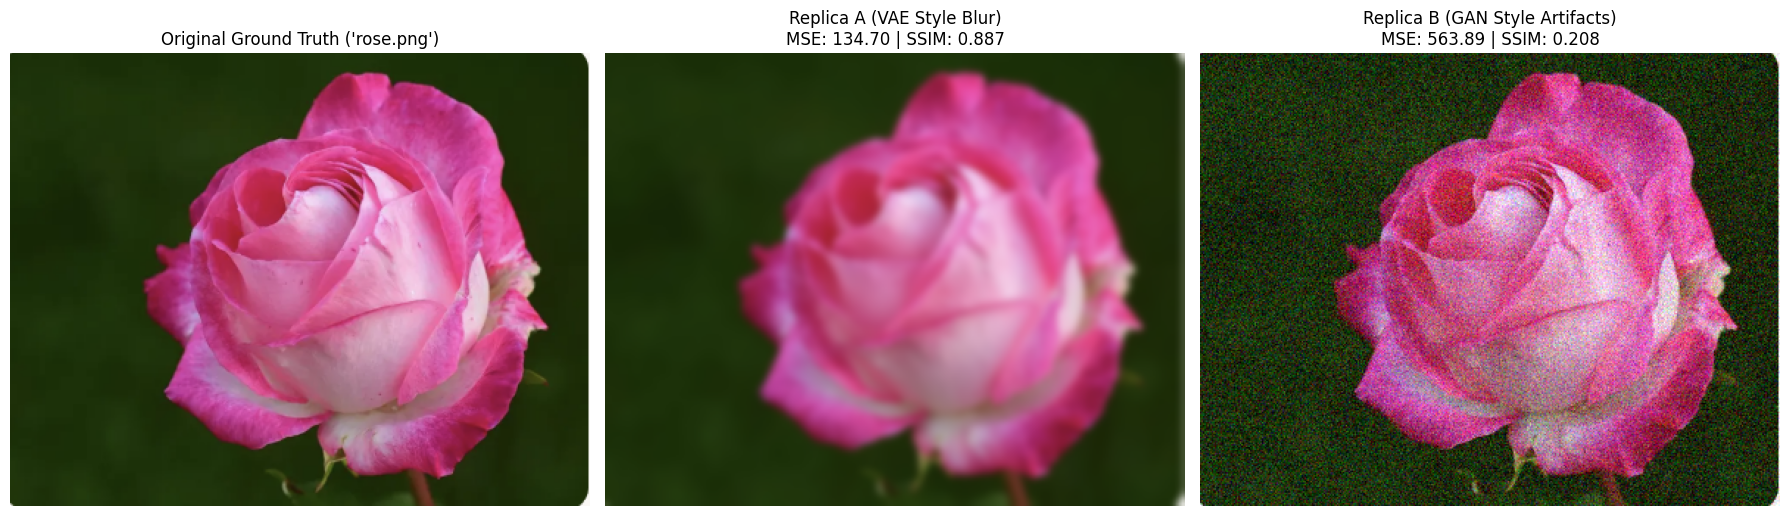

🖼️ VISUAL METRICS BRIEF:
• Replica A (Blur): MSE = 134.70, SSIM = 0.887
• Replica B (Noise): MSE = 563.89, SSIM = 0.208

Key Perceptual Concept:
Notice how Replica A has a lower MSE and significantly higher SSIM because it preserves
the broad geometric layout, whereas the pixel-level disruptions in Replica B drastically
penalize its structural integrity scores, despite retaining sharp details.


In [ ]:
#To print image without Gradio
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# --- CORE IMAGE EVALUATION LOGIC ---
def run_image_evaluation(image_path):
    # 1. Load the original reference image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Make sure '{image_path}' is present in your working directory.")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Simulate standard generative model imperfections
    # Replica A: Simulates VAE blurriness
    replica_a_rgb = cv2.GaussianBlur(img_rgb, (15, 15), 0)
    replica_a_gray = cv2.GaussianBlur(img_gray, (15, 15), 0)

    # Replica B: Simulates GAN noise/checkerboard artifacts
    noise = np.random.normal(0, 25, img_gray.shape).astype(np.int16)
    replica_b_gray = np.clip(img_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Re-build RGB for Replica B visualization
    noise_rgb = np.random.normal(0, 25, img_rgb.shape).astype(np.int16)
    replica_b_rgb = np.clip(img_rgb.astype(np.int16) + noise_rgb, 0, 255).astype(np.uint8)

    # 3. Calculate Image Metrics
    mse_a = np.mean((img_gray.astype(np.float32) - replica_a_gray.astype(np.float32)) ** 2)
    ssim_a = ssim(img_gray, replica_a_gray)

    mse_b = np.mean((img_gray.astype(np.float32) - replica_b_gray.astype(np.float32)) ** 2)
    ssim_b = ssim(img_gray, replica_b_gray)

    # 4. Generate Visual Comparison Layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Ground Truth ('rose.png')")
    axes[0].axis('off')

    axes[1].imshow(replica_a_rgb)
    axes[1].set_title(f"Replica A (VAE Style Blur)\nMSE: {mse_a:.2f} | SSIM: {ssim_a:.3f}")
    axes[1].axis('off')

    axes[2].imshow(replica_b_rgb)
    axes[2].set_title(f"Replica B (GAN Style Artifacts)\nMSE: {mse_b:.2f} | SSIM: {ssim_b:.3f}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()  # Explicitly forces the 3-panel comparison to render inline!
    plt.close()

    # 5. Build Text Summary
    summary_text = (
        f"🖼️ VISUAL METRICS BRIEF:\n"
        f"• Replica A (Blur): MSE = {mse_a:.2f}, SSIM = {ssim_a:.3f}\n"
        f"• Replica B (Noise): MSE = {mse_b:.2f}, SSIM = {ssim_b:.3f}\n\n"
        f"Key Perceptual Concept:\n"
        f"Notice how Replica A has a lower MSE and significantly higher SSIM because it preserves\n"
        f"the broad geometric layout, whereas the pixel-level disruptions in Replica B drastically\n"
        f"penalize its structural integrity scores, despite retaining sharp details."
    )
    return summary_text

# ==========================================
#  👇 THE ACTIVE FUNCTION CALL TRIGGER 👇
# ==========================================

# Run the live image assessment and print the perceptual report
image_report = run_image_evaluation("rose.png")
print(image_report)